# Entry Signal Check
Answers: **is this a valid tactical entry right now?**

Set the candidate ticker and price below. Three gates must pass:
1. **Catalyst** — qualitative, your call (not checked here)
2. **Technical confirmation** — volume, relative strength, momentum, not extended
3. **R:R gate** — implied loss from ATR stop must be ≤ 7%

If all three pass, a suggested position size is output.

#### Imports and Policy Load

In [ ]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib

import geoquant.configs.config as config
import geoquant.data_io as data_io
import geoquant.indicators as indicators
from geoquant.decision_policy import load_decision_policy

importlib.reload(data_io)
importlib.reload(indicators)

policy = load_decision_policy()
rules  = policy['rules']
print('Policy loaded')


Policy loaded


#### Candidate Parameters

In [8]:
# ── CANDIDATE PARAMETERS ── edit these ────────────────────────────────────────
TICKER            = 'BATG.LSE'     # candidate ticker
GBX               = True           # True if LSE penny stock (price in pence)
CANDIDATE_PRICE   = None           # your intended entry price; None = use latest close
PORTFOLIO_CHF     = 52000          # total portfolio value in CHF (for position sizing)
CATALYST          = 'describe catalyst here'  # qualitative — gate 1 (your call)

# ── GATE THRESHOLDS (from policy / literature) ─────────────────────────────────
ATR_WINDOW        = 14
ATR_STOP_MULT     = rules['exit']['hard_stop_multiple_atr']   # 2.5
MAX_LOSS_PCT      = 0.07           # R:R gate: implied stop loss must be ≤ 7% from entry
MAX_EXTENDED_PCT  = 0.10           # don't enter if price >10% above 20d high
MIN_VOL_RATIO     = 1.5            # volume confirmation: today vs 20d avg
RISK_PER_TRADE    = 0.015          # max portfolio loss if stop fires (1.5%)
BENCHMARK_TICKER  = 'XMWX.LSE'    # relative strength benchmark
RS_WINDOW_DAYS    = 63             # ~3 months

print(f'Candidate: {TICKER}  |  catalyst: "{CATALYST}"')
print(f'Portfolio: CHF {PORTFOLIO_CHF:,}  |  risk/trade: {RISK_PER_TRADE:.1%}')

Candidate: BATG.LSE  |  catalyst: "describe catalyst here"
Portfolio: CHF 52,000  |  risk/trade: 1.5%


#### Data Fetch

In [9]:
# ── FETCH PRICES ──────────────────────────────────────────────────────────────
today     = pd.Timestamp.today().normalize()
lookback  = today - pd.Timedelta(days=120)   # enough for ATR warm-up + RS window

fetch_params = dict(config.data_params)
fetch_params['start'] = lookback
fetch_params['end']   = today

raw = data_io.fetch_csv(TICKER, fetch_params)
raw = raw.loc[lookback:today]

bm_params = dict(fetch_params)
raw_bm = data_io.fetch_csv(BENCHMARK_TICKER, bm_params)
raw_bm = raw_bm.loc[lookback:today]

if GBX:
    raw[['Open', 'High', 'Low', 'Close']] /= 100.0

print(f'{TICKER}: {len(raw)} rows  {raw.index[0].date()} → {raw.index[-1].date()}')
print(f'{BENCHMARK_TICKER}: {len(raw_bm)} rows')
raw.tail(3)

BATG.LSE: 83 rows  2026-01-16 → 2026-05-15
XMWX.LSE: 83 rows


,Open,High,Low,Close,Volume
Date,,,,,
2026-05-13,30.235,30.675,30.015,30.460,38903
2026-05-14,30.160,30.300,29.500,29.915,29903
2026-05-15,29.600,29.605,28.640,28.950,41882


#### Signal Computation

In [ ]:
# ── COMPUTE SIGNALS ───────────────────────────────────────────────────────────
df = raw[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

df['ATR'] = indicators.compute_atr(df, ATR_WINDOW)

# Volume ratio vs 20d average
df['vol_20d_avg'] = df['Volume'].rolling(20).mean()
df['vol_ratio']   = df['Volume'] / df['vol_20d_avg']

# 20d high (for "not extended" check)
df['high_20d'] = df['High'].rolling(20).max()

# Momentum: 20d slope direction (close > close 20 bars ago)
df['momentum_20d'] = df['Close'] > df['Close'].shift(20)

# Relative strength vs benchmark (RS_WINDOW_DAYS return)
rs_ticker = df['Close'].pct_change(RS_WINDOW_DAYS).iloc[-1]
bm_close  = raw_bm['Close'] if 'Close' in raw_bm.columns else raw_bm.iloc[:, 0]
rs_bm     = bm_close.pct_change(RS_WINDOW_DAYS).iloc[-1]
rs_outperforming = rs_ticker > rs_bm

# Candidate price
latest = df.iloc[-1]
candidate_price = CANDIDATE_PRICE if CANDIDATE_PRICE is not None else latest['Close']

print(f'Latest close: {latest["Close"]:.4f}  |  candidate entry: {candidate_price:.4f}')
print(f'ATR (latest): {latest["ATR"]:.4f}  ({latest["ATR"]/candidate_price:.2%} of price)')


Latest close: 28.9500  |  candidate entry: 28.9500
ATR (latest): 0.7649  (2.64% of price)


#### Gate Evaluation

In [ ]:
# ── GATE EVALUATION ───────────────────────────────────────────────────────────
atr_latest       = latest['ATR']
implied_stop     = candidate_price - ATR_STOP_MULT * atr_latest
implied_loss_pct = (candidate_price - implied_stop) / candidate_price

vol_ratio_latest   = latest['vol_ratio']
high_20d_latest    = latest['high_20d']
pct_above_20d_high = (candidate_price - high_20d_latest) / high_20d_latest
momentum_ok        = bool(latest['momentum_20d'])

# Gate results
# Note: volume is advisory only — catalyst-driven entries precede the crowd;
#       high volume is a breakout signal, not a requirement here.
g1_catalyst  = CATALYST.strip() not in ('', 'describe catalyst here')
g2_rs        = rs_outperforming
g2_extended  = pct_above_20d_high <= MAX_EXTENDED_PCT
g2_momentum  = momentum_ok
g2_pass      = g2_rs and g2_extended and g2_momentum
g3_rr        = implied_loss_pct <= MAX_LOSS_PCT

vol_advisory = vol_ratio_latest >= MIN_VOL_RATIO   # informational only

all_pass = g1_catalyst and g2_pass and g3_rr

# Position sizing
max_loss_chf     = PORTFOLIO_CHF * RISK_PER_TRADE
loss_per_share   = candidate_price * implied_loss_pct
suggested_shares = int(max_loss_chf / loss_per_share) if loss_per_share > 0 else 0
position_value   = suggested_shares * candidate_price
position_weight  = position_value / PORTFOLIO_CHF

# ── REPORT ────────────────────────────────────────────────────────────────────
PASS = '✓'
FAIL = '✗'
INFO = '○'   # advisory — not a gate

print(f'═══ ENTRY SIGNAL CHECK: {TICKER} ══════════════════════════════════')
print(f'  Candidate price : {candidate_price:.4f}')
print(f'  ATR stop        : {implied_stop:.4f}  (−{implied_loss_pct:.1%} from entry)')
print()
print(f'  GATE 1 — Catalyst          {PASS if g1_catalyst else FAIL}  "{CATALYST}"')
print(f'  GATE 2 — Technical')
print(f'    Relative strength vs bm   {PASS if g2_rs else FAIL}  ticker {rs_ticker:+.1%}  bm {rs_bm:+.1%}  ({RS_WINDOW_DAYS}d)')
print(f'    Not extended              {PASS if g2_extended else FAIL}  {pct_above_20d_high:+.1%} vs 20d high  (max +{MAX_EXTENDED_PCT:.0%})')
print(f'    Momentum direction        {PASS if g2_momentum else FAIL}  close > close 20d ago')
print(f'    Volume (advisory)         {INFO}  {vol_ratio_latest:.2f}x vs 20d avg  ({"above" if vol_advisory else "below"} {MIN_VOL_RATIO}x threshold)')
print(f'  GATE 3 — R:R               {PASS if g3_rr else FAIL}  implied loss {implied_loss_pct:.1%}  (max {MAX_LOSS_PCT:.0%})')
print()
if all_pass:
    print(f'  *** ALL GATES PASS ***')
    print(f'  Suggested entry     : {candidate_price:.4f}  ×  {suggested_shares} shares')
    print(f'  Position value      : CHF {position_value:,.0f}  ({position_weight:.1%} of portfolio)')
    print(f'  Max loss if stopped : CHF {max_loss_chf:,.0f}  ({RISK_PER_TRADE:.1%} of portfolio)')
    print(f'  Set stop at         : {implied_stop:.4f}')
else:
    failed = []
    if not g1_catalyst: failed.append('Gate 1: no catalyst specified')
    if not g2_rs:       failed.append(f'Gate 2: underperforming benchmark ({rs_ticker:+.1%} vs {rs_bm:+.1%})')
    if not g2_extended: failed.append(f'Gate 2: too extended ({pct_above_20d_high:+.1%} above 20d high)')
    if not g2_momentum: failed.append('Gate 2: momentum negative')
    if not g3_rr:       failed.append(f'Gate 3: R:R too wide ({implied_loss_pct:.1%} > {MAX_LOSS_PCT:.0%})')
    print(f'  *** ENTRY NOT VALID ***')
    for f in failed:
        print(f'    — {f}')


═══ ENTRY SIGNAL CHECK: BATG.LSE ══════════════════════════════════
  Candidate price : 28.9500
  ATR stop        : 27.0377  (−6.6% from entry)

  GATE 1 — Catalyst          ✗  "describe catalyst here"
  GATE 2 — Technical
    Volume ratio (vs 20d avg) ✗  1.15x  (need ≥1.5x)
    Relative strength vs bm   ✓  ticker +21.5%  bm +0.6%  (63d)
    Not extended              ✓  -6.9% vs 20d high  (max +10%)
    Momentum direction        ✓  close > close 20d ago
  GATE 3 — R:R               ✓  implied loss 6.6%  (max 7%)

  *** ENTRY NOT VALID ***
    — Gate 1: no catalyst specified
    — Gate 2: volume 1.15x < 1.5x


#### Price Chart

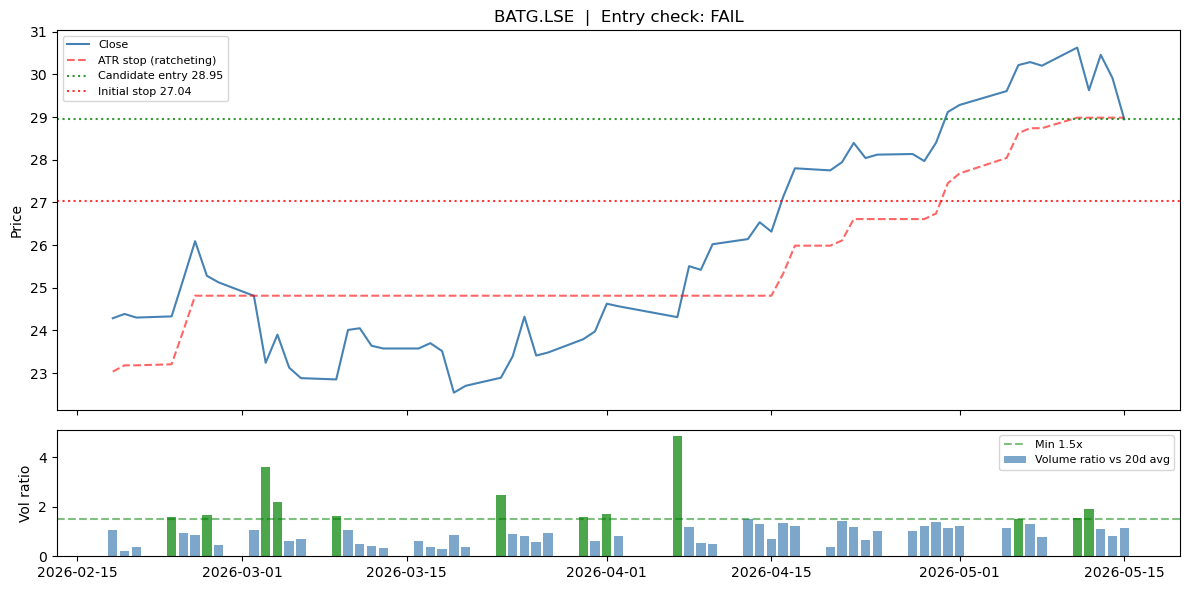

In [ ]:
# ── PRICE CHART WITH ATR STOP AND ENTRY LEVEL ─────────────────────────────────
plot_df = df.iloc[-60:].copy()   # last 60 bars

stop_curve = indicators.atr_ratchet_stop(plot_df['Close'], plot_df['ATR'], ATR_STOP_MULT)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(plot_df.index, plot_df['Close'], color='steelblue', label='Close')
ax1.plot(plot_df.index, stop_curve, color='red', linestyle='--', alpha=0.6, label='ATR stop (ratcheting)')
ax1.axhline(candidate_price, color='green', linestyle=':', alpha=0.8, label=f'Candidate entry {candidate_price:.2f}')
ax1.axhline(implied_stop,    color='red',   linestyle=':',  alpha=0.8, label=f'Initial stop {implied_stop:.2f}')
ax1.set_ylabel('Price')
ax1.set_title(f'{TICKER}  |  Entry check: {"PASS" if all_pass else "FAIL"}')
ax1.legend(fontsize=8)

ax2.bar(plot_df.index, plot_df['vol_ratio'], color=[
    'green' if v >= MIN_VOL_RATIO else 'steelblue' for v in plot_df['vol_ratio']
], alpha=0.7, label='Volume ratio vs 20d avg')
ax2.axhline(MIN_VOL_RATIO, color='green', linestyle='--', alpha=0.5, label=f'Min {MIN_VOL_RATIO}x')
ax2.set_ylabel('Vol ratio')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()
